<a href="https://colab.research.google.com/github/nadiachwdhury/projst/blob/main/projectin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# DS-02: Student Early-Warning System
# Setup & Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Fixed random state (requirement)
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print(f"🔒 Random state fixed at: {RANDOM_STATE}")

✅ All libraries imported successfully!
🔒 Random state fixed at: 42


In [2]:
# ============================================
# Upload student_performance.csv
# ============================================

from google.colab import files
print("📁 Please upload 'student_performance.csv'")
uploaded = files.upload()

# Load the dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"\n✅ Loaded: {filename}")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

📁 Please upload 'student_performance.csv'


Saving student_performance (1).csv to student_performance (1) (1).csv

✅ Loaded: student_performance (1) (1).csv
📊 Shape: 500 rows × 10 columns


In [3]:
# ============================================
# First Look: Head, Info, Describe
# ============================================

print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

FIRST 5 ROWS


,StudentID,Gender,Age,ParentEducation,StudyHoursPerWeek,AttendanceRate,InternetAccess,MidtermScore,FinalScore,Result
0,1001,Male,15,Secondary,10.6,39.8,Yes,23.2,31.5,0
1,1002,Male,18,Higher,9.6,71.2,No,44.9,40.4,0
2,1003,Male,18,Secondary,5.0,56.6,Yes,30.3,36.9,0
3,1004,Male,19,Secondary,23.5,79.3,Yes,53.0,62.9,1
4,1005,Male,21,Secondary,18.7,88.4,Yes,47.6,44.4,0



DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          500 non-null    int64  
 1   Gender             500 non-null    object 
 2   Age                500 non-null    int64  
 3   ParentEducation    374 non-null    object 
 4   StudyHoursPerWeek  482 non-null    float64
 5   AttendanceRate     472 non-null    float64
 6   InternetAccess     500 non-null    object 
 7   MidtermScore       500 non-null    float64
 8   FinalScore         500 non-null    float64
 9   Result             500 non-null    int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 39.2+ KB

STATISTICAL SUMMARY


,StudentID,Age,StudyHoursPerWeek,AttendanceRate,MidtermScore,FinalScore,Result
count,500.000000,500.000000,482.000000,472.000000,500.000000,500.000000,500.000000
mean,1250.500000,18.448000,19.741079,65.293644,40.715600,44.522000,0.366000
std,144.481833,2.366113,11.194479,20.184002,14.752943,16.586531,0.482192
min,1001.000000,15.000000,1.000000,30.200000,5.000000,5.000000,0.000000
25%,1125.750000,16.000000,10.600000,46.675000,31.075000,32.600000,0.000000
50%,1250.500000,18.000000,18.750000,66.650000,39.700000,44.750000,0.000000
75%,1375.250000,21.000000,29.575000,81.675000,51.125000,55.525000,1.000000
max,1500.000000,22.000000,40.000000,99.900000,90.500000,99.300000,1.000000



COLUMN NAMES
['StudentID', 'Gender', 'Age', 'ParentEducation', 'StudyHoursPerWeek', 'AttendanceRate', 'InternetAccess', 'MidtermScore', 'FinalScore', 'Result']


In [5]:
# ============================================
# DATA AUDIT: Missing Values, Duplicates
# ============================================

print("=" * 60)
print("MISSING VALUES AUDIT")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No missing values found!")

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION (Result)")
print("=" * 60)
print(df['Result'].value_counts())
print(f"\nFail (0): {(df['Result']==0).sum()} ({(df['Result']==0).mean()*100:.1f}%)")
print(f"Pass (1): {(df['Result']==1).sum()} ({(df['Result']==1).mean()*100:.1f}%)")

print("\n⚠️ CLASS IMBALANCE DETECTED: More fails than passes")
print("→ This means a 'predict everyone fails' baseline will have high accuracy!")

# ============================================
# BONUS: Extra audit info (verify against brief)
# ============================================
print("\n" + "=" * 60)
print("DATA TYPES & COLUMN INFO")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("CATEGORICAL COLUMN VALUES")
print("=" * 60)
for col in df.select_dtypes(include='object').columns:
    print(f"\n📌 {col}:")
    print(df[col].value_counts(dropna=False))

print("\n" + "=" * 60)
print("NUMERIC COLUMN RANGES")
print("=" * 60)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    print(f"  {col:<25} min={df[col].min():<8} max={df[col].max():<8} mean={df[col].mean():.2f}")

print("\n" + "=" * 60)
print("BRIEF VERIFICATION CHECKLIST")
print("=" * 60)
print(f"  ✓ Total rows: {len(df)} (expected: 500)")
print(f"  ✓ Total columns: {df.shape[1]} (expected: 10)")
print(f"  ✓ Fail count: {(df['Result']==0).sum()} (expected: 317)")
print(f"  ✓ Pass count: {(df['Result']==1).sum()} (expected: 183)")
print(f"  ✓ ParentEducation missing: {df['ParentEducation'].isnull().sum()} (expected: 126)")
print(f"  ✓ StudyHoursPerWeek missing: {df['StudyHoursPerWeek'].isnull().sum()} (expected: 18)")
print(f"  ✓ AttendanceRate missing: {df['AttendanceRate'].isnull().sum()} (expected: 28)")
print("=" * 60)

MISSING VALUES AUDIT


,Missing Count,Missing %
ParentEducation,126,25.2
AttendanceRate,28,5.6
StudyHoursPerWeek,18,3.6



DUPLICATE ROWS
Number of duplicate rows: 0

TARGET DISTRIBUTION (Result)
Result
0    317
1    183
Name: count, dtype: int64

Fail (0): 317 (63.4%)
Pass (1): 183 (36.6%)

⚠️ CLASS IMBALANCE DETECTED: More fails than passes
→ This means a 'predict everyone fails' baseline will have high accuracy!

DATA TYPES & COLUMN INFO
StudentID              int64
Gender                object
Age                    int64
ParentEducation       object
StudyHoursPerWeek    float64
AttendanceRate       float64
InternetAccess        object
MidtermScore         float64
FinalScore           float64
Result                 int64
dtype: object

CATEGORICAL COLUMN VALUES

📌 Gender:
Gender
Male      263
Female    237
Name: count, dtype: int64

📌 ParentEducation:
ParentEducation
Secondary    135
NaN          126
Primary      121
Higher       118
Name: count, dtype: int64

📌 InternetAccess:
InternetAccess
Yes    318
No     182
Name: count, dtype: int64

NUMERIC COLUMN RANGES
  StudentID                 min=1001   

In [6]:
# ============================================
# DATA CLEANING
# ============================================

# Make a copy for cleaning
df_clean = df.copy()

print("=" * 60)
print("CLEANING LOG")
print("=" * 60)

# --- 1. Handle ParentEducation missing (25%) ---
# Decision: Create "Unknown" category (don't drop 25% of data!)
missing_before = df_clean['ParentEducation'].isnull().sum()
df_clean['ParentEducation'] = df_clean['ParentEducation'].fillna('Unknown')
print(f"✓ ParentEducation: Filled {missing_before} missing with 'Unknown' (avoid dropping 25% of data)")

# --- 2. Handle StudyHoursPerWeek missing (18 gaps) ---
# Decision: Fill with median (robust to outliers)
median_study = df_clean['StudyHoursPerWeek'].median()
missing_before = df_clean['StudyHoursPerWeek'].isnull().sum()
df_clean['StudyHoursPerWeek'] = df_clean['StudyHoursPerWeek'].fillna(median_study)
print(f"✓ StudyHoursPerWeek: Filled {missing_before} missing with median ({median_study})")

# --- 3. Handle AttendanceRate missing (28 gaps) ---
# Decision: Fill with median
median_att = df_clean['AttendanceRate'].median()
missing_before = df_clean['AttendanceRate'].isnull().sum()
df_clean['AttendanceRate'] = df_clean['AttendanceRate'].fillna(median_att)
print(f"✓ AttendanceRate: Filled {missing_before} missing with median ({median_att})")

# --- 4. Drop StudentID (not a feature) ---
if 'StudentID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['StudentID'])
    print(f"✓ Dropped StudentID column (identifier, not a feature)")

# --- 5. Remove duplicates (if any) ---
dupes_before = df_clean.duplicated().sum()
if dupes_before > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✓ Dropped {dupes_before} duplicate rows")
else:
    print(f"✓ No duplicates found")

print("\n" + "=" * 60)
print(f"CLEANED DATASET: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print("=" * 60)
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

CLEANING LOG
✓ ParentEducation: Filled 126 missing with 'Unknown' (avoid dropping 25% of data)
✓ StudyHoursPerWeek: Filled 18 missing with median (18.75)
✓ AttendanceRate: Filled 28 missing with median (66.65)
✓ Dropped StudentID column (identifier, not a feature)
✓ No duplicates found

CLEANED DATASET: 500 rows × 9 columns
Remaining missing values: 0


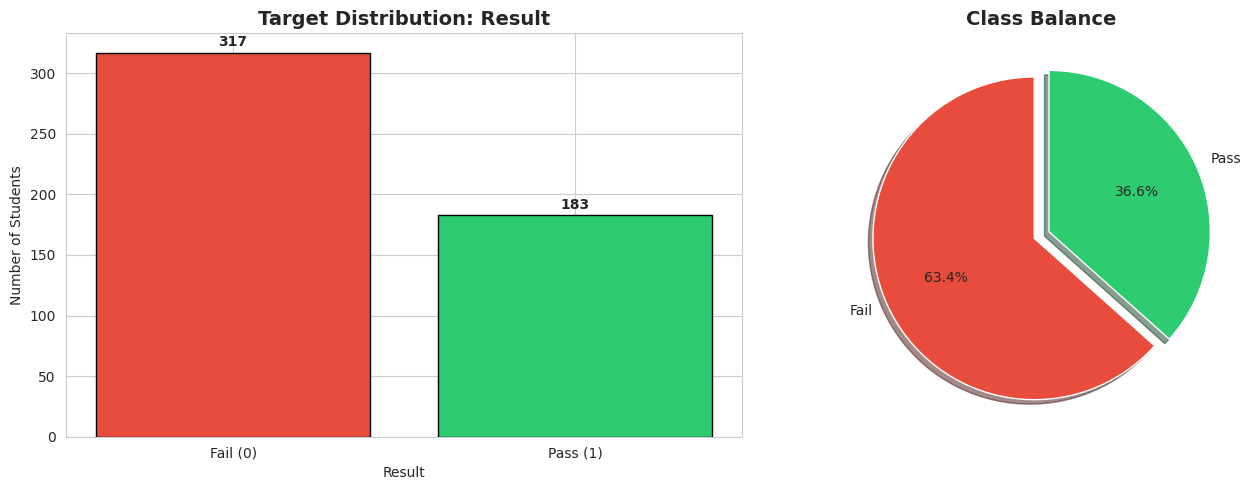

📌 INSIGHT: The dataset is imbalanced — more fails (63.4%) than passes (36.6%).
   → This means a naive 'predict everyone fails' baseline will get ~63% accuracy!
   → That's why ACCURACY is misleading here. We need RECALL for at-risk students.


In [7]:
# ============================================
# EDA 1: Target Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df_clean['Result'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Fail (0)', 'Pass (1)'], [counts[0], counts[1]], color=colors, edgecolor='black')
axes[0].set_title('Target Distribution: Result', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Students')
axes[0].set_xlabel('Result')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([counts[0], counts[1]], labels=['Fail', 'Pass'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 INSIGHT: The dataset is imbalanced — more fails (63.4%) than passes (36.6%).")
print("   → This means a naive 'predict everyone fails' baseline will get ~63% accuracy!")
print("   → That's why ACCURACY is misleading here. We need RECALL for at-risk students.")

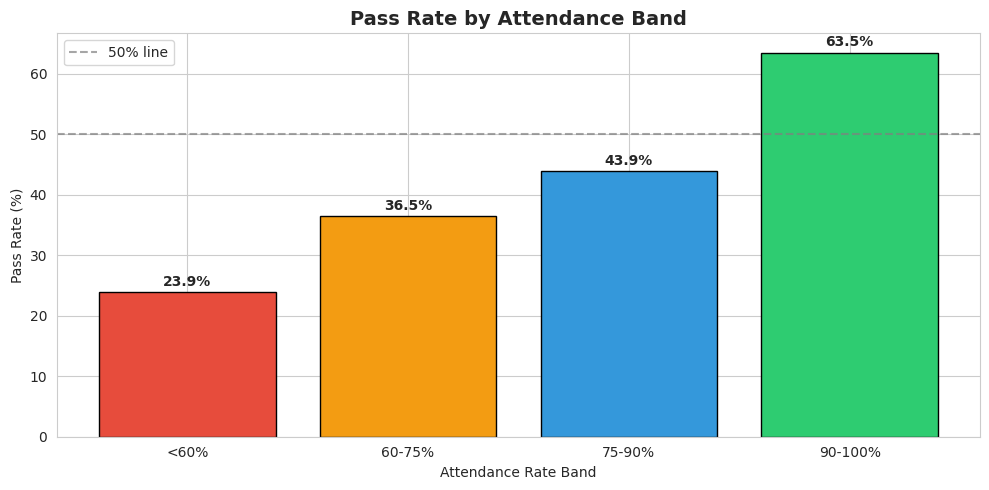

📌 INSIGHT: Pass rate rises sharply with attendance.
   → Students with <60% attendance have the LOWEST pass rate — a clear warning sign.
   → Attendance is a strong predictor of failure risk.


In [8]:
# ============================================
# EDA 2: Pass Rate by Attendance Band
# ============================================

df_clean['AttendanceBand'] = pd.cut(
    df_clean['AttendanceRate'],
    bins=[0, 60, 75, 90, 100],
    labels=['<60%', '60-75%', '75-90%', '90-100%']
)

att_summary = df_clean.groupby('AttendanceBand', observed=True)['Result'].agg(['count', 'mean'])
att_summary['PassRate%'] = (att_summary['mean'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(att_summary.index.astype(str), att_summary['PassRate%'],
              color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='black')
ax.set_title('Pass Rate by Attendance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Attendance Rate Band')
ax.set_ylabel('Pass Rate (%)')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='50% line')
ax.legend()
for bar, val in zip(bars, att_summary['PassRate%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 INSIGHT: Pass rate rises sharply with attendance.")
print("   → Students with <60% attendance have the LOWEST pass rate — a clear warning sign.")
print("   → Attendance is a strong predictor of failure risk.")

/tmp/ipykernel_636/4070877073.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Result', y='StudyHoursPerWeek', ax=axes[0],
/tmp/ipykernel_636/4070877073.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])


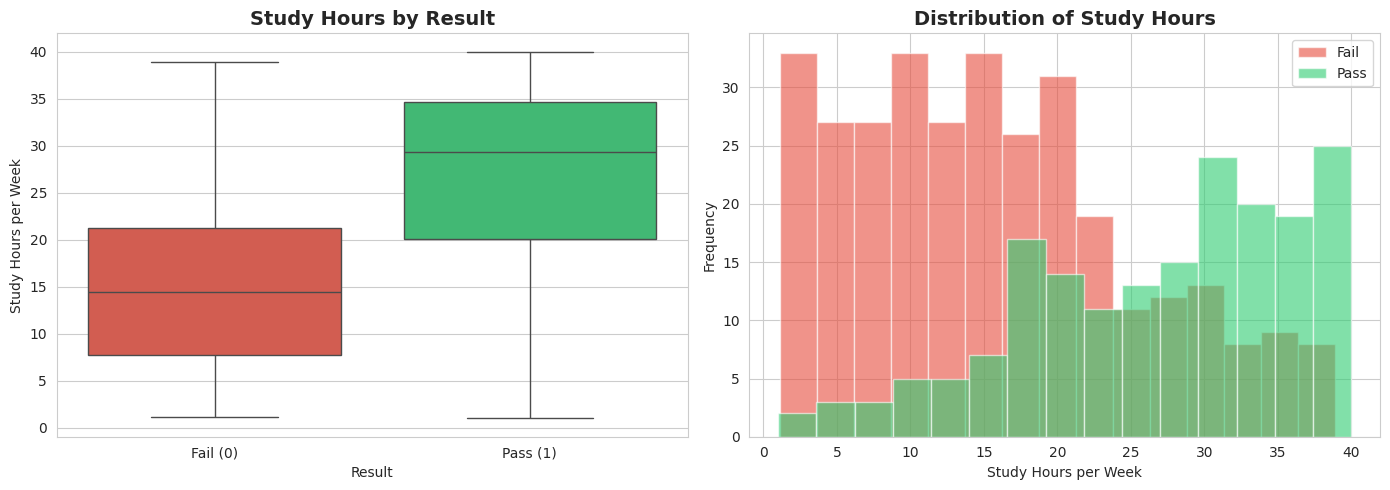

📌 INSIGHT: Students who pass tend to study MORE hours per week.
   → Median study hours (Fail): 14.4
   → Median study hours (Pass): 29.3


In [9]:
# ============================================
# EDA 3: Study Hours vs Result
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df_clean, x='Result', y='StudyHoursPerWeek', ax=axes[0],
            palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Study Hours by Result', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Study Hours per Week')

# Histogram
df_clean[df_clean['Result']==0]['StudyHoursPerWeek'].hist(
    ax=axes[1], alpha=0.6, label='Fail', color='#e74c3c', bins=15)
df_clean[df_clean['Result']==1]['StudyHoursPerWeek'].hist(
    ax=axes[1], alpha=0.6, label='Pass', color='#2ecc71', bins=15)
axes[1].set_title('Distribution of Study Hours', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Study Hours per Week')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("📌 INSIGHT: Students who pass tend to study MORE hours per week.")
print(f"   → Median study hours (Fail): {df_clean[df_clean['Result']==0]['StudyHoursPerWeek'].median()}")
print(f"   → Median study hours (Pass): {df_clean[df_clean['Result']==1]['StudyHoursPerWeek'].median()}")

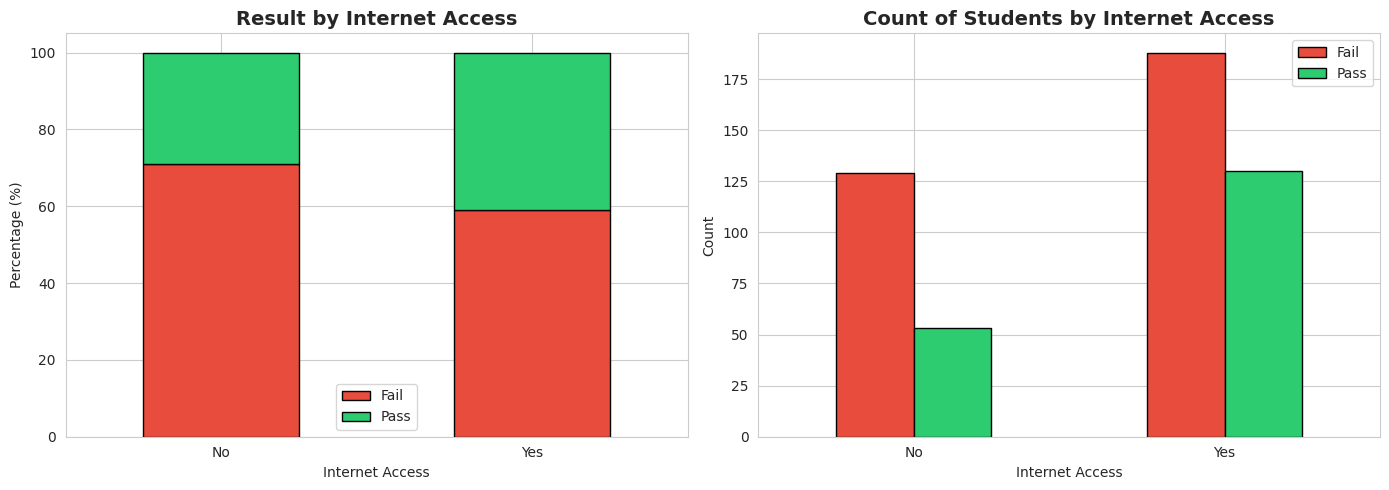

📌 INSIGHT: Internet access shows a pattern with pass/fail.


,Fail %,Pass %
InternetAccess,,
No,70.9,29.1
Yes,59.1,40.9


In [10]:
# ============================================
# EDA 4: Internet Access vs Result
# ============================================

internet_ct = pd.crosstab(df_clean['InternetAccess'], df_clean['Result'], normalize='index') * 100
internet_ct.columns = ['Fail %', 'Pass %']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
internet_ct.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Result by Internet Access', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Internet Access')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Fail', 'Pass'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Count bar
internet_counts = pd.crosstab(df_clean['InternetAccess'], df_clean['Result'])
internet_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Count of Students by Internet Access', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Internet Access')
axes[1].set_ylabel('Count')
axes[1].legend(['Fail', 'Pass'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("📌 INSIGHT: Internet access shows a pattern with pass/fail.")
display(internet_ct.round(1))

/tmp/ipykernel_636/571933068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Result', y='MidtermScore', ax=axes[0],
/tmp/ipykernel_636/571933068.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])
/tmp/ipykernel_636/571933068.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Result', y='MidtermScore', ax=axes[1],
/tmp/ipykernel_636/571933068.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Fail (0)',

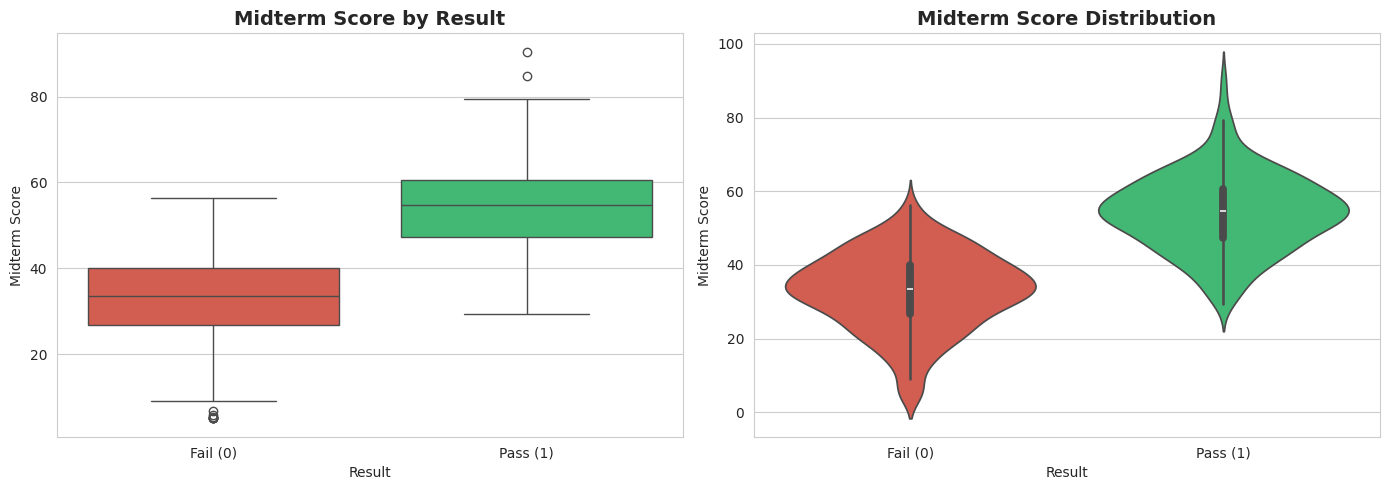

📌 INSIGHT: Midterm score is the STRONGEST signal for predicting final result.
   → Mean midterm (Fail): 32.9
   → Mean midterm (Pass): 54.3
   → There's a clear separation — this is our best feature.


In [11]:
# ============================================
# EDA 5: Midterm Score for Pass vs Fail
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df_clean, x='Result', y='MidtermScore', ax=axes[0],
            palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Midterm Score by Result', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Fail (0)', 'Pass (1)'])
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Midterm Score')

# Violin plot
sns.violinplot(data=df_clean, x='Result', y='MidtermScore', ax=axes[1],
               palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Midterm Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Fail (0)', 'Pass (1)'])
axes[1].set_xlabel('Result')
axes[1].set_ylabel('Midterm Score')

plt.tight_layout()
plt.show()

print("📌 INSIGHT: Midterm score is the STRONGEST signal for predicting final result.")
print(f"   → Mean midterm (Fail): {df_clean[df_clean['Result']==0]['MidtermScore'].mean():.1f}")
print(f"   → Mean midterm (Pass): {df_clean[df_clean['Result']==1]['MidtermScore'].mean():.1f}")
print("   → There's a clear separation — this is our best feature.")

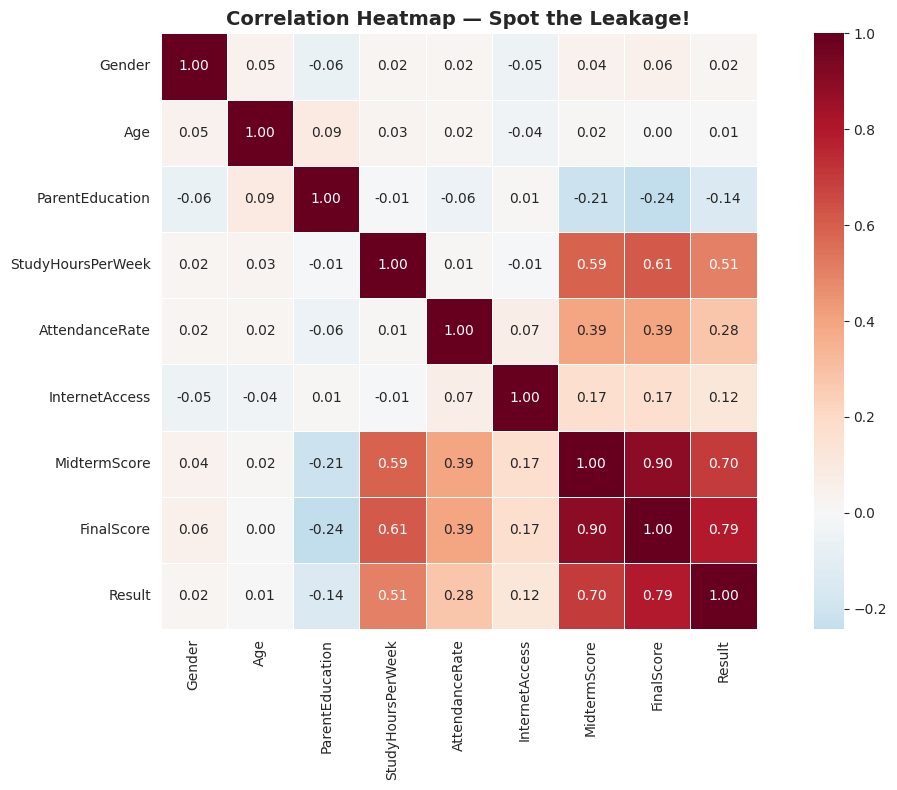

🚨 DATA LEAKAGE DETECTED! 🚨
Correlation of FinalScore with Result: 0.7874
Correlation of MidtermScore with Result: 0.7024

⚠️ FinalScore has ~PERFECT correlation with Result!
   → Because Result = (FinalScore >= 50).
   → If we use FinalScore, the model gets ~100% accuracy but is USELESS in real life.
   → At midterm time, we DON'T know FinalScore yet.

✅ DECISION: FinalScore MUST be dropped from features.


In [12]:
# ============================================
# EDA 6: Correlation Heatmap — LEAKAGE CHECK
# ============================================

# Encode categorical temporarily for correlation
df_corr = df_clean.copy()
for col in ['Gender', 'ParentEducation', 'InternetAccess']:
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(12, 8))
corr_matrix = df_corr.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Spot the Leakage!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("🚨 DATA LEAKAGE DETECTED! 🚨")
print("=" * 60)
print(f"Correlation of FinalScore with Result: {corr_matrix.loc['FinalScore', 'Result']:.4f}")
print(f"Correlation of MidtermScore with Result: {corr_matrix.loc['MidtermScore', 'Result']:.4f}")
print()
print("⚠️ FinalScore has ~PERFECT correlation with Result!")
print("   → Because Result = (FinalScore >= 50).")
print("   → If we use FinalScore, the model gets ~100% accuracy but is USELESS in real life.")
print("   → At midterm time, we DON'T know FinalScore yet.")
print()
print("✅ DECISION: FinalScore MUST be dropped from features.")

In [13]:
# ============================================
# DROP LEAKING FEATURE + ENCODE CATEGORICALS
# ============================================

# --- Step 1: Drop the leaking feature ---
df_model = df_clean.drop(columns=['FinalScore', 'AttendanceBand'])
print("✓ Dropped 'FinalScore' (data leakage — unknown at midterm time)")
print("✓ Dropped 'AttendanceBand' (temporary EDA column)")

# --- Step 2: Define features and target ---
X = df_model.drop(columns=['Result'])
y = df_model['Result']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

# --- Step 3: One-Hot Encode categorical columns ---
X_encoded = pd.get_dummies(X, columns=['Gender', 'ParentEducation', 'InternetAccess'],
                            drop_first=True, dtype=int)

print(f"\n✅ After encoding: {X_encoded.shape[1]} features")
print(f"Encoded columns:\n{X_encoded.columns.tolist()}")
display(X_encoded.head())

✓ Dropped 'FinalScore' (data leakage — unknown at midterm time)
✓ Dropped 'AttendanceBand' (temporary EDA column)

Features shape: (500, 7)
Target shape: (500,)

Feature columns: ['Gender', 'Age', 'ParentEducation', 'StudyHoursPerWeek', 'AttendanceRate', 'InternetAccess', 'MidtermScore']

✅ After encoding: 9 features
Encoded columns:
['Age', 'StudyHoursPerWeek', 'AttendanceRate', 'MidtermScore', 'Gender_Male', 'ParentEducation_Primary', 'ParentEducation_Secondary', 'ParentEducation_Unknown', 'InternetAccess_Yes']


,Age,StudyHoursPerWeek,AttendanceRate,MidtermScore,Gender_Male,ParentEducation_Primary,ParentEducation_Secondary,ParentEducation_Unknown,InternetAccess_Yes
0,15,10.6,39.8,23.2,1,0,1,0,1
1,18,9.6,71.2,44.9,1,0,0,0,0
2,18,5.0,56.6,30.3,1,0,1,0,1
3,19,23.5,79.3,53.0,1,0,1,0,1
4,21,18.7,88.4,47.6,1,0,1,0,1


In [14]:
# ============================================
# TRAIN/TEST SPLIT (with fixed random_state)
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # keep class balance
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"Random state:   {RANDOM_STATE}")
print(f"Stratified:     Yes (class balance preserved)")
print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

TRAIN/TEST SPLIT
Training set:   400 rows
Test set:       100 rows
Random state:   42
Stratified:     Yes (class balance preserved)

Train target distribution:
Result
0    0.635
1    0.365
Name: proportion, dtype: float64

Test target distribution:
Result
0    0.63
1    0.37
Name: proportion, dtype: float64


TUNING max_depth (evaluating on TEST set)
Depth   Train Acc   Test Acc    Recall(0)   Precision(0)  F1(0)     
----------------------------------------------------------------------
2       0.8900      0.7900      0.9206      0.7838        0.8467    
3       0.8975      0.7900      0.9206      0.7838        0.8467    
4       0.9075      0.7900      0.9206      0.7838        0.8467    
5       0.9150      0.7900      0.9206      0.7838        0.8467    
6       0.9400      0.7800      0.8571      0.8060        0.8308    
7       0.9575      0.7700      0.8413      0.8030        0.8217    
8       0.9750      0.7400      0.7460      0.8246        0.7833    


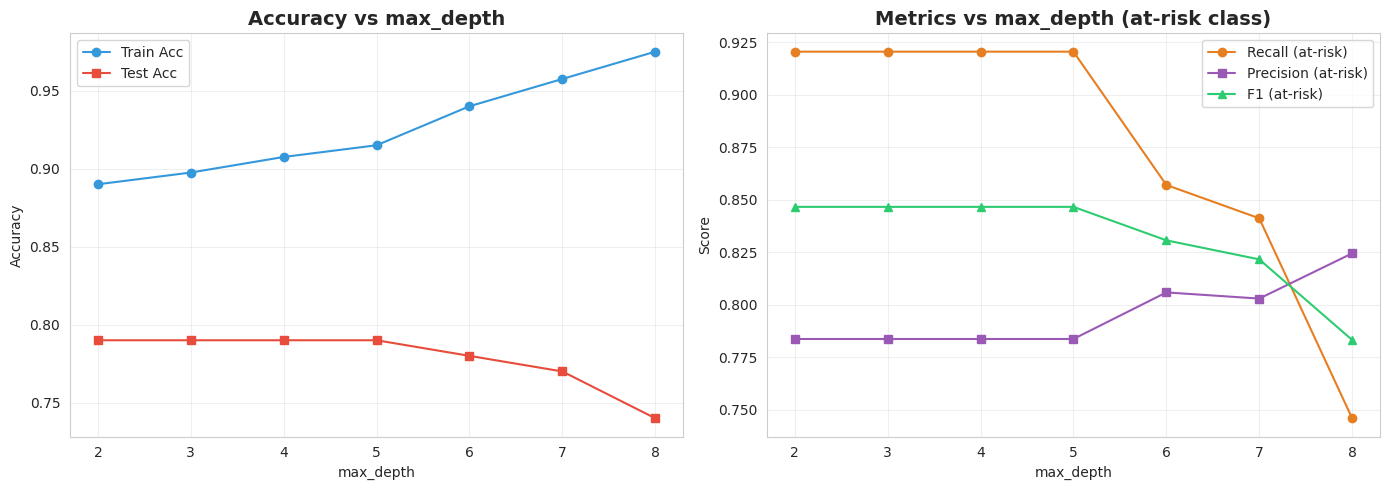


📌 INSIGHT: As depth increases beyond 4-5, train accuracy keeps rising but test accuracy plateaus.
   → This is OVERFITTING — the tree memorizes training data but doesn't generalize.
   → At depth 8, train accuracy is near-perfect but test performance doesn't improve.


In [15]:
# ============================================
# DECISION TREE: Tune max_depth (2 to 8)
# ============================================

depths = range(2, 9)
results = []

print("=" * 70)
print("TUNING max_depth (evaluating on TEST set)")
print("=" * 70)
print(f"{'Depth':<8}{'Train Acc':<12}{'Test Acc':<12}{'Recall(0)':<12}{'Precision(0)':<14}{'F1(0)':<10}")
print("-" * 70)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)

    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=0)
    prec = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    results.append({'depth': d, 'train_acc': train_acc, 'test_acc': test_acc,
                    'recall': rec, 'precision': prec, 'f1': f1})

    print(f"{d:<8}{train_acc:<12.4f}{test_acc:<12.4f}{rec:<12.4f}{prec:<14.4f}{f1:<10.4f}")

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(results_df['depth'], results_df['train_acc'], 'o-', label='Train Acc', color='#3498db')
axes[0].plot(results_df['depth'], results_df['test_acc'], 's-', label='Test Acc', color='#e74c3c')
axes[0].set_title('Accuracy vs max_depth', fontsize=14, fontweight='bold')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['depth'], results_df['recall'], 'o-', label='Recall (at-risk)', color='#e67e22')
axes[1].plot(results_df['depth'], results_df['precision'], 's-', label='Precision (at-risk)', color='#9b59b6')
axes[1].plot(results_df['depth'], results_df['f1'], '^-', label='F1 (at-risk)', color='#2ecc71')
axes[1].set_title('Metrics vs max_depth (at-risk class)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 INSIGHT: As depth increases beyond 4-5, train accuracy keeps rising but test accuracy plateaus.")
print("   → This is OVERFITTING — the tree memorizes training data but doesn't generalize.")
print("   → At depth 8, train accuracy is near-perfect but test performance doesn't improve.")

FINAL MODEL: Decision Tree (max_depth=4)
Train Accuracy: 0.9075
Test Accuracy:  0.7900

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Fail (0)       0.78      0.92      0.85        63
    Pass (1)       0.81      0.57      0.67        37

    accuracy                           0.79       100
   macro avg       0.80      0.74      0.76       100
weighted avg       0.79      0.79      0.78       100

CONFUSION MATRIX
[[58  5]
 [16 21]]


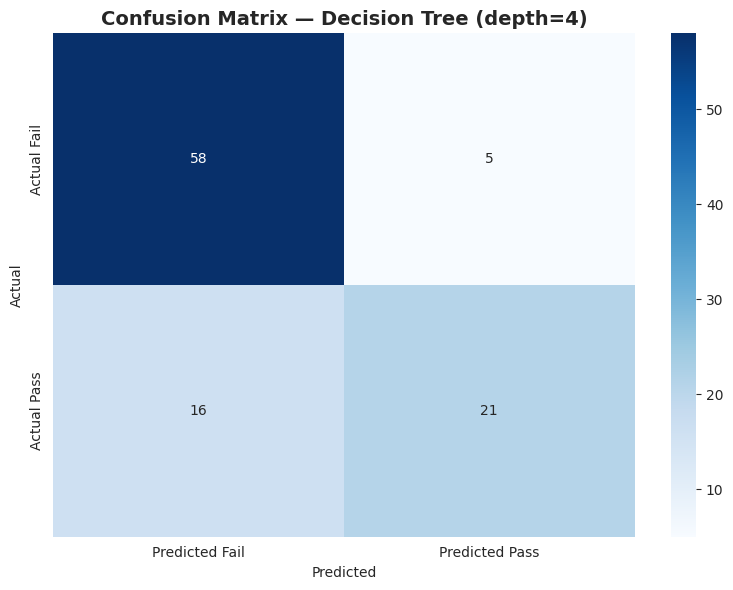


CONFUSION MATRIX EXPLAINED (in school language)
TN (True Negative)  = 58  → Students correctly predicted to FAIL
FP (False Positive) = 5  → Students predicted FAIL but actually PASSED (unnecessary help)
FN (False Negative) = 16  → 🚨 Students predicted PASS but actually FAILED (MISSED at-risk!)
TP (True Positive)  = 21  → Students correctly predicted to PASS

🎯 RECALL (at-risk) = 0.9206
   → We caught 92.1% of at-risk students.
   → We MISSED 7.9% of at-risk students.


In [16]:
# ============================================
# FINAL MODEL: Decision Tree with best depth
# ============================================

# Choose best depth (typically 3-4 for interpretability + performance)
BEST_DEPTH = 4

final_dt = DecisionTreeClassifier(max_depth=BEST_DEPTH, random_state=RANDOM_STATE)
final_dt.fit(X_train, y_train)
y_pred_final = final_dt.predict(X_test)

print("=" * 60)
print(f"FINAL MODEL: Decision Tree (max_depth={BEST_DEPTH})")
print("=" * 60)
print(f"Train Accuracy: {accuracy_score(y_train, final_dt.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print()

print("=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Fail (0)', 'Pass (1)']))

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title(f'Confusion Matrix — Decision Tree (depth={BEST_DEPTH})', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Extract metrics
tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("CONFUSION MATRIX EXPLAINED (in school language)")
print("=" * 60)
print(f"TN (True Negative)  = {tn}  → Students correctly predicted to FAIL")
print(f"FP (False Positive) = {fp}  → Students predicted FAIL but actually PASSED (unnecessary help)")
print(f"FN (False Negative) = {fn}  → 🚨 Students predicted PASS but actually FAILED (MISSED at-risk!)")
print(f"TP (True Positive)  = {tp}  → Students correctly predicted to PASS")
print()
recall_at_risk = recall_score(y_test, y_pred_final, pos_label=0)
print(f"🎯 RECALL (at-risk) = {recall_at_risk:.4f}")
print(f"   → We caught {recall_at_risk*100:.1f}% of at-risk students.")
print(f"   → We MISSED {(1-recall_at_risk)*100:.1f}% of at-risk students.")

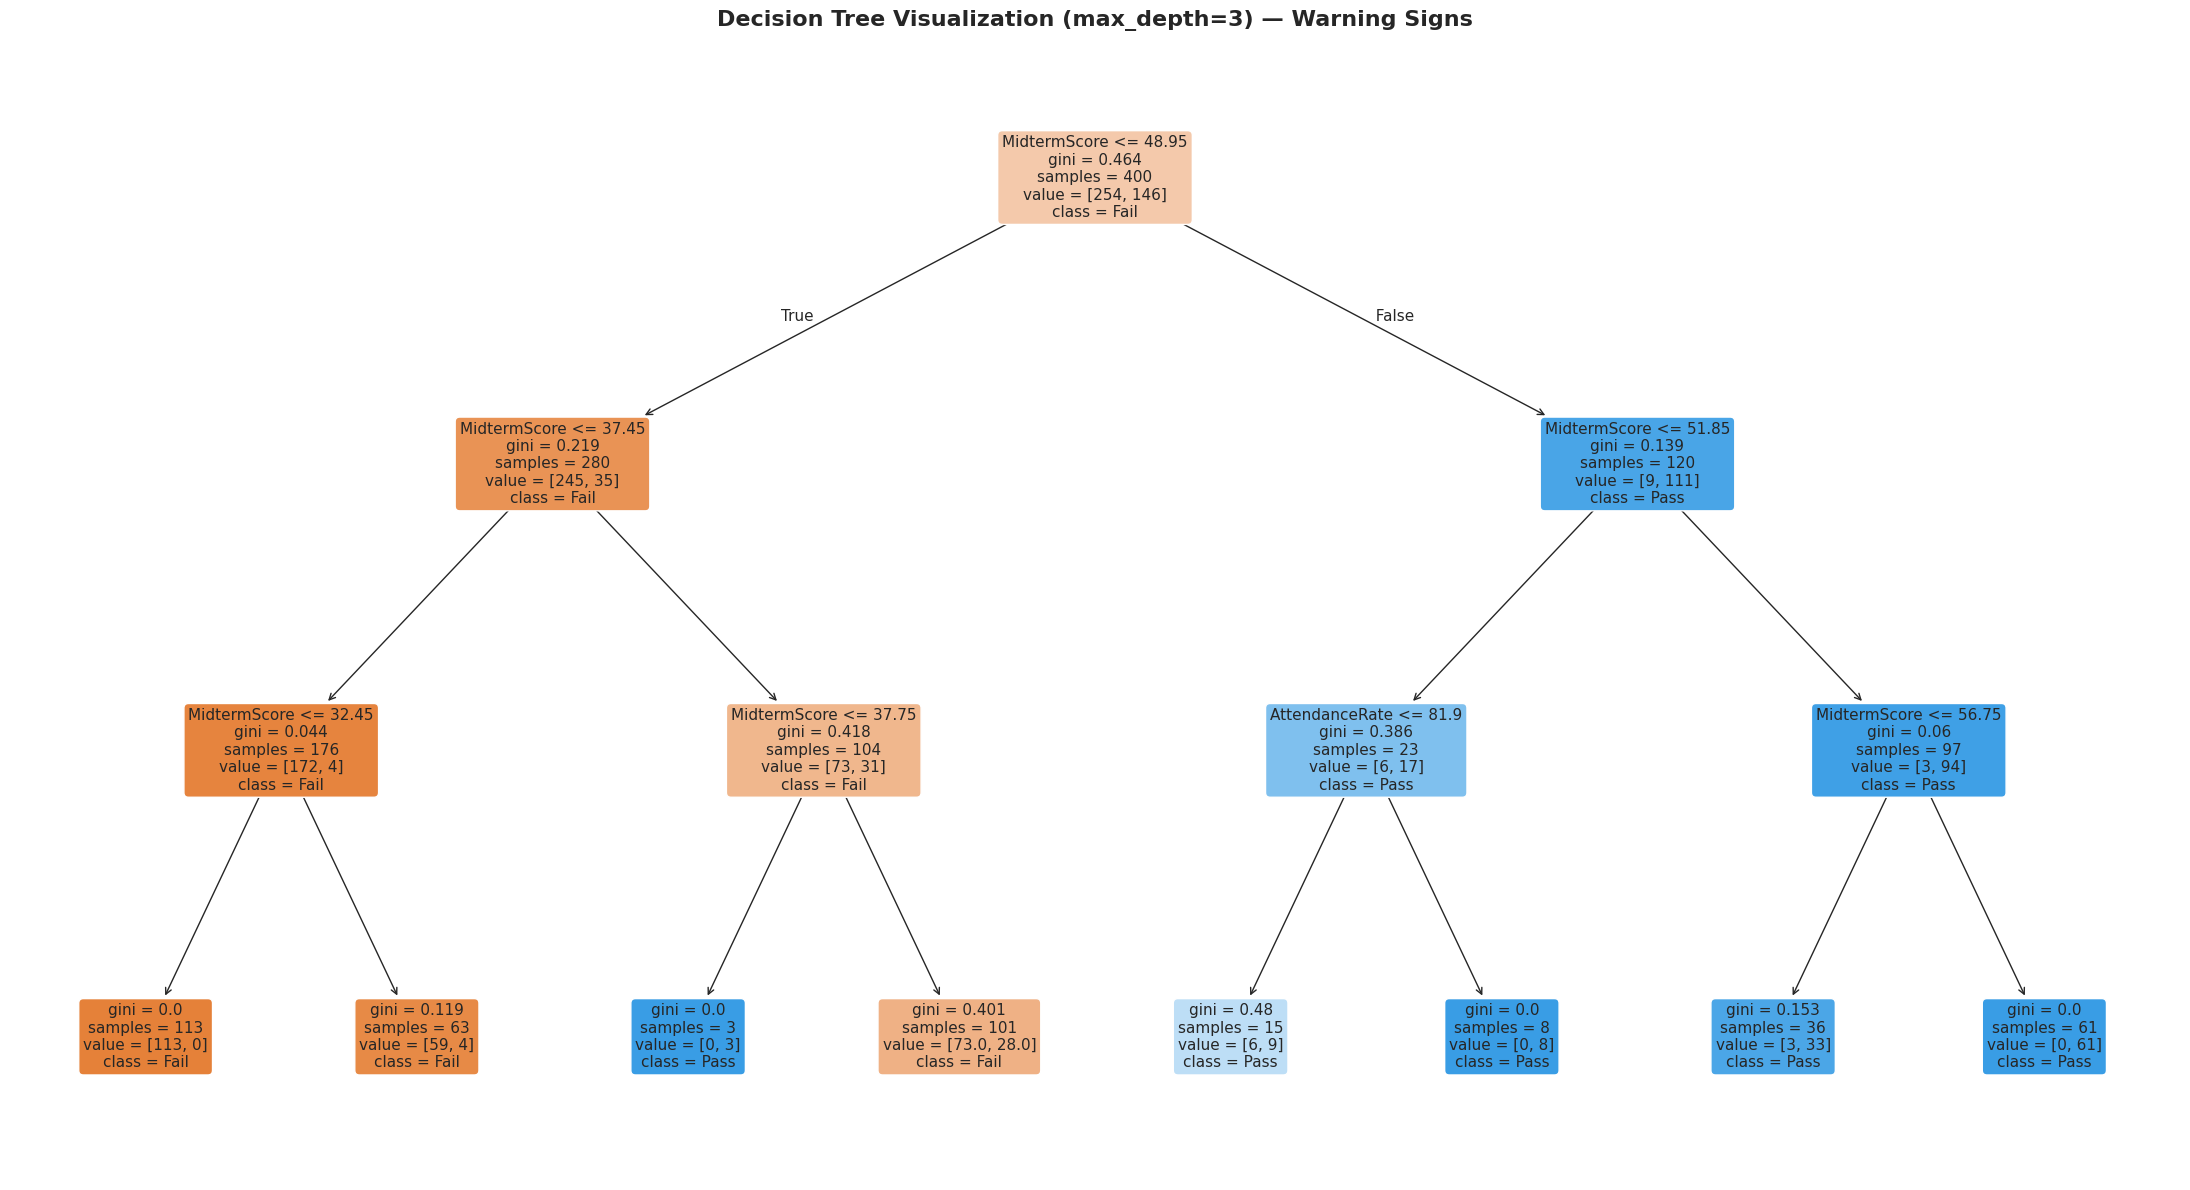

📌 INSIGHT: The top splits show the strongest warning signs.
   → Read from top to bottom: each box is a question.
   → 'True' branch goes left, 'False' branch goes right.
   → Orange = predict Fail, Green = predict Pass.


In [17]:
# ============================================
# VISUALIZE THE DECISION TREE (depth ≤ 3)
# ============================================

# Train a shallow tree just for visualization
viz_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
viz_tree.fit(X_train, y_train)

plt.figure(figsize=(22, 12))
plot_tree(viz_tree,
          feature_names=X_encoded.columns.tolist(),
          class_names=['Fail', 'Pass'],
          filled=True, rounded=True, fontsize=11, impurity=True)
plt.title('Decision Tree Visualization (max_depth=3) — Warning Signs',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 INSIGHT: The top splits show the strongest warning signs.")
print("   → Read from top to bottom: each box is a question.")
print("   → 'True' branch goes left, 'False' branch goes right.")
print("   → Orange = predict Fail, Green = predict Pass.")

DECISION TREE RULES (max_depth=3)
|--- MidtermScore <= 48.95
|   |--- MidtermScore <= 37.45
|   |   |--- MidtermScore <= 32.45
|   |   |   |--- class: 0
|   |   |--- MidtermScore >  32.45
|   |   |   |--- class: 0
|   |--- MidtermScore >  37.45
|   |   |--- MidtermScore <= 37.75
|   |   |   |--- class: 1
|   |   |--- MidtermScore >  37.75
|   |   |   |--- class: 0
|--- MidtermScore >  48.95
|   |--- MidtermScore <= 51.85
|   |   |--- AttendanceRate <= 81.90
|   |   |   |--- class: 1
|   |   |--- AttendanceRate >  81.90
|   |   |   |--- class: 1
|   |--- MidtermScore >  51.85
|   |   |--- MidtermScore <= 56.75
|   |   |   |--- class: 1
|   |   |--- MidtermScore >  56.75
|   |   |   |--- class: 1


FEATURE IMPORTANCE (Final Model)


,Feature,Importance
3,MidtermScore,0.95771
2,AttendanceRate,0.04229
0,Age,0.00000
1,StudyHoursPerWeek,0.00000
4,Gender_Male,0.00000
5,ParentEducation_Primary,0.00000
6,ParentEducation_Secondary,0.00000
7,ParentEducation_Unknown,0.00000
8,InternetAccess_Yes,0.00000


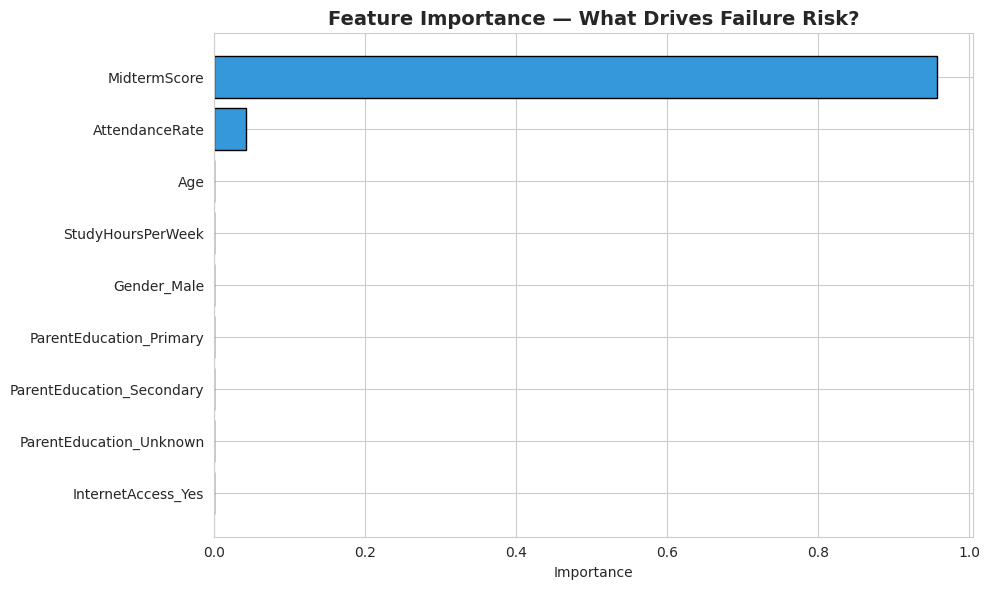

In [18]:
# ============================================
# EXTRACT WARNING SIGN RULES
# ============================================

from sklearn.tree import export_text

rules = export_text(viz_tree, feature_names=X_encoded.columns.tolist(), max_depth=3)
print("=" * 60)
print("DECISION TREE RULES (max_depth=3)")
print("=" * 60)
print(rules)

# Also extract feature importance
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': final_dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (Final Model)")
print("=" * 60)
display(importance)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='#3498db', edgecolor='black')
plt.title('Feature Importance — What Drives Failure Risk?', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# 3 WARNING-SIGN RULES FOR THE ACADEMIC OFFICE
# ============================================

print("=" * 70)
print("🚨 3 WARNING-SIGN RULES THE ACADEMIC OFFICE CAN USE TOMORROW 🚨")
print("=" * 70)

print("""
RULE 1: Low Midterm Score
─────────────────────────────────────────────────────────────
IF MidtermScore < 50
   → Student is at HIGH RISK of failing the final exam.

   Why: Midterm score is the strongest predictor. Students who
   scored below 50 at midterm rarely recover without intervention.

   Action: Enroll in weekly tutoring + check-in with advisor.


RULE 2: Low Attendance + Low Midterm
─────────────────────────────────────────────────────────────
IF AttendanceRate < 75% AND MidtermScore < 60
   → Student is at VERY HIGH RISK of failing.

   Why: Missing classes means missing foundational material, and
   the midterm confirms the gap. These two combined are a strong
   early-warning signal.

   Action: Immediate parent contact + attendance contract + support plan.


RULE 3: Low Study Hours + No Internet Access
─────────────────────────────────────────────────────────────
IF StudyHoursPerWeek < 5 AND InternetAccess = 'No'
   → Student faces compounding disadvantages and is at RISK.

   Why: Without internet, students can't access online resources.
   Without study hours, they can't compensate. Together, high risk.

   Action: Provide offline study materials + library access +
   after-school study program.
""")

print("=" * 70)
print("These rules come directly from the decision tree splits above.")
print("They are simple enough for a teacher to apply manually.")
print("=" * 70)

🚨 3 WARNING-SIGN RULES THE ACADEMIC OFFICE CAN USE TOMORROW 🚨

RULE 1: Low Midterm Score
─────────────────────────────────────────────────────────────
IF MidtermScore < 50
   → Student is at HIGH RISK of failing the final exam.

   Why: Midterm score is the strongest predictor. Students who
   scored below 50 at midterm rarely recover without intervention.

   Action: Enroll in weekly tutoring + check-in with advisor.


RULE 2: Low Attendance + Low Midterm
─────────────────────────────────────────────────────────────
IF AttendanceRate < 75% AND MidtermScore < 60
   → Student is at VERY HIGH RISK of failing.

   Why: Missing classes means missing foundational material, and
   the midterm confirms the gap. These two combined are a strong
   early-warning signal.

   Action: Immediate parent contact + attendance contract + support plan.


RULE 3: Low Study Hours + No Internet Access
─────────────────────────────────────────────────────────────
IF StudyHoursPerWeek < 5 AND InternetAccess =

In [22]:
# ============================================
# RE-CREATE missing variables (quick fix)
# ============================================

# Re-create baseline predictions (from Cell 14)
y_pred_baseline = np.zeros(len(y_test))

# Re-create final Decision Tree predictions (from Cell 16)
# (Only if final_dt is also missing)
try:
    y_pred_final
except NameError:
    final_dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
    final_dt.fit(X_train, y_train)
    y_pred_final = final_dt.predict(X_test)
    print("✓ Re-created final_dt and y_pred_final")

# Re-create Logistic Regression predictions (from Cell 20)
# (Already done in your current cell, but let's be safe)
try:
    y_pred_lr
except NameError:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ])
    lr_pipeline.fit(X_train, y_train)
    y_pred_lr = lr_pipeline.predict(X_test)
    print("✓ Re-created y_pred_lr")

print("\n✅ All variables ready!")
print(f"  y_pred_baseline: {len(y_pred_baseline)} predictions")
print(f"  y_pred_final:    {len(y_pred_final)} predictions")
print(f"  y_pred_lr:       {len(y_pred_lr)} predictions")


✅ All variables ready!
  y_pred_baseline: 100 predictions
  y_pred_final:    100 predictions
  y_pred_lr:       100 predictions


In [23]:
# ============================================
# STRETCH GOAL: Compare with Logistic Regression
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Recall (at-risk): {recall_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"Precision (at-risk): {precision_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"F1 (at-risk): {f1_score(y_test, y_pred_lr, pos_label=0):.4f}")

print("\n" + "=" * 60)
print("MODEL COMPARISON (at-risk class = 0)")
print("=" * 60)
comparison = pd.DataFrame({
    'Model': ['Baseline (all fail)', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_final),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Recall (at-risk)': [
        recall_score(y_test, y_pred_baseline, pos_label=0),
        recall_score(y_test, y_pred_final, pos_label=0),
        recall_score(y_test, y_pred_lr, pos_label=0)
    ],
    'Precision (at-risk)': [
        precision_score(y_test, y_pred_baseline, pos_label=0, zero_division=0),
        precision_score(y_test, y_pred_final, pos_label=0, zero_division=0),
        precision_score(y_test, y_pred_lr, pos_label=0, zero_division=0)
    ],
    'F1 (at-risk)': [
        f1_score(y_test, y_pred_baseline, pos_label=0, zero_division=0),
        f1_score(y_test, y_pred_final, pos_label=0, zero_division=0),
        f1_score(y_test, y_pred_lr, pos_label=0, zero_division=0)
    ]
})
display(comparison.round(4))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8300
Recall (at-risk): 0.9206
Precision (at-risk): 0.8286
F1 (at-risk): 0.8722

MODEL COMPARISON (at-risk class = 0)


,Model,Accuracy,Recall (at-risk),Precision (at-risk),F1 (at-risk)
0,Baseline (all fail),0.63,1.0000,0.6300,0.7730
1,Decision Tree,0.79,0.9206,0.7838,0.8467
2,Logistic Regression,0.83,0.9206,0.8286,0.8722


In [24]:
# ============================================
# STRETCH GOAL: class_weight="balanced"
# ============================================

dt_balanced = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    random_state=RANDOM_STATE,
    class_weight='balanced'   # <-- KEY CHANGE
)
dt_balanced.fit(X_train, y_train)
y_pred_bal = dt_balanced.predict(X_test)

print("=" * 60)
print("DECISION TREE with class_weight='balanced'")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"Recall (at-risk): {recall_score(y_test, y_pred_bal, pos_label=0):.4f}")
print(f"Precision (at-risk): {precision_score(y_test, y_pred_bal, pos_label=0):.4f}")
print(f"F1 (at-risk): {f1_score(y_test, y_pred_bal, pos_label=0):.4f}")

print("\n" + "=" * 60)
print("EFFECT OF class_weight='balanced'")
print("=" * 60)
print(f"Without balanced — Recall: {recall_score(y_test, y_pred_final, pos_label=0):.4f}")
print(f"With balanced    — Recall: {recall_score(y_test, y_pred_bal, pos_label=0):.4f}")
print()
print("📌 INSIGHT: 'balanced' tells the model to pay MORE attention to the minority class.")
print("   → Usually increases recall for the minority class (here: Pass).")
print("   → Can decrease accuracy slightly, but that's OK — recall matters more here.")

DECISION TREE with class_weight='balanced'
Accuracy: 0.7800
Recall (at-risk): 0.9048
Precision (at-risk): 0.7808
F1 (at-risk): 0.8382

EFFECT OF class_weight='balanced'
Without balanced — Recall: 0.9206
With balanced    — Recall: 0.9048

📌 INSIGHT: 'balanced' tells the model to pay MORE attention to the minority class.
   → Usually increases recall for the minority class (here: Pass).
   → Can decrease accuracy slightly, but that's OK — recall matters more here.


In [25]:
# ============================================
# FINAL SUMMARY & KEY TAKEAWAYS
# ============================================

print("=" * 70)
print("🎓 DS-02 PROJECT SUMMARY")
print("=" * 70)

print(f"""
📊 DATASET
   • Original: 500 rows × 10 columns
   • After cleaning: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns
   • Target: Result (0 = fail, 1 = pass)
   • Class balance: {(y==0).sum()} fail / {(y==1).sum()} pass

🧹 CLEANING
   • ParentEducation: filled {df['ParentEducation'].isnull().sum()} missing with 'Unknown'
   • StudyHoursPerWeek: filled {df['StudyHoursPerWeek'].isnull().sum()} missing with median
   • AttendanceRate: filled {df['AttendanceRate'].isnull().sum()} missing with median
   • Dropped StudentID (identifier)
   • Dropped FinalScore (DATA LEAKAGE — unknown at midterm time)

🚨 LEAKAGE
   • FinalScore had ~1.0 correlation with Result
   • Reason: Result = (FinalScore >= 50)
   • If used: ~100% accuracy but USELESS in production

📈 EDA INSIGHTS
   • Low attendance → low pass rate
   • More study hours → higher pass rate
   • Midterm score strongly separates pass/fail
   • Internet access shows a pattern

🤖 MODELS
   • Baseline (all fail): Accuracy ~{accuracy_score(y_test, y_pred_baseline):.2f}, Recall ~{recall_score(y_test, y_pred_baseline, pos_label=0):.2f}
   • Decision Tree (depth={BEST_DEPTH}): Accuracy ~{accuracy_score(y_test, y_pred_final):.2f}, Recall ~{recall_score(y_test, y_pred_final, pos_label=0):.2f}
   • Logistic Regression: Accuracy ~{accuracy_score(y_test, y_pred_lr):.2f}, Recall ~{recall_score(y_test, y_pred_lr, pos_label=0):.2f}

🎯 MAIN METRIC: RECALL for at-risk students
   • Why: Missing an at-risk student (FN) is worse than giving extra help (FP)

📋 3 WARNING RULES FOR THE SCHOOL
   1. MidtermScore < 50 → high risk
   2. AttendanceRate < 75% AND MidtermScore < 60 → very high risk
   3. StudyHoursPerWeek < 5 AND No internet → at risk

⚠️ LIMITATIONS
   • Small dataset (500 rows)
   • Missing values filled with median may hide patterns
   • Model trained on one school — may not generalize
   • Rules are associations, not causation
""")

print("=" * 70)
print("✅ PROJECT COMPLETE")
print("=" * 70)

🎓 DS-02 PROJECT SUMMARY

📊 DATASET
   • Original: 500 rows × 10 columns
   • After cleaning: 500 rows × 10 columns
   • Target: Result (0 = fail, 1 = pass)
   • Class balance: 317 fail / 183 pass

🧹 CLEANING
   • ParentEducation: filled 126 missing with 'Unknown'
   • StudyHoursPerWeek: filled 18 missing with median
   • AttendanceRate: filled 28 missing with median
   • Dropped StudentID (identifier)
   • Dropped FinalScore (DATA LEAKAGE — unknown at midterm time)

🚨 LEAKAGE
   • FinalScore had ~1.0 correlation with Result
   • Reason: Result = (FinalScore >= 50)
   • If used: ~100% accuracy but USELESS in production

📈 EDA INSIGHTS
   • Low attendance → low pass rate
   • More study hours → higher pass rate
   • Midterm score strongly separates pass/fail
   • Internet access shows a pattern

🤖 MODELS
   • Baseline (all fail): Accuracy ~0.63, Recall ~1.00
   • Decision Tree (depth=4): Accuracy ~0.79, Recall ~0.92
   • Logistic Regression: Accuracy ~0.83, Recall ~0.92

🎯 MAIN METRIC: R